# Probabilistic forecasting on a rotating Gaussian mixture

Reproduces the first experiment in
[Probabilistic Forecasting with Stochastic Interpolants and Föllmer Processes](https://arxiv.org/abs/2403.13724).

**Setup.** The stationary distribution is a mixture of `N` 2D Gaussians whose
means lie on a ring of radius 5 and whose covariances are aligned tangentially.
The reference dynamics is an overdamped Langevin SDE for the currently-active
component, plus a Poisson clock (rate `lam`) that rotates the state by
`2*pi/N` and advances to the next component. We train a stochastic interpolant (with point source)
to forecast the next snapshot `X_{t+1}` given `X_t`.


In [32]:
import math
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.distributions as dist
import torch.utils.data

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, MultipleLocator
import seaborn as sns
import scipy.stats as stats


In [33]:
# Plot style
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5.0
plt.rcParams['xtick.minor.size'] = 3.0
plt.rcParams['ytick.major.size'] = 5.0
plt.rcParams['ytick.minor.size'] = 3.0
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['legend.handlelength'] = 2.0


## 1. Target distribution

`N_MIXTURE = 5` Gaussians on a ring of radius 5. Component `i` has mean
`5 * (cos(i*A), sin(i*A))` with `A = 2*pi/N`, and covariance `R_i diag(1.5, 0.1) R_i^T`
(an anisotropic blob rotated by `i*A`).


In [34]:
N_MIXTURE = 5
RADIUS = 5.0
MAJOR_VAR, MINOR_VAR = 1.5, 0.1
ANGLE = 2 * math.pi / N_MIXTURE


def rotation_matrix(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s], [s, c]])


def _component_mean(i):
    return RADIUS * np.array([np.cos(i * ANGLE), np.sin(i * ANGLE)])


def _component_cov(i):
    R_i = rotation_matrix(i * ANGLE)
    C0 = np.diag([MAJOR_VAR, MINOR_VAR])
    return R_i @ C0 @ R_i.T


weights = np.ones(N_MIXTURE) / N_MIXTURE
mus = np.stack([_component_mean(i) for i in range(N_MIXTURE)])
Cs = np.stack([_component_cov(i) for i in range(N_MIXTURE)])

target = dist.MixtureSameFamily(
    dist.Categorical(torch.tensor(weights)),
    dist.MultivariateNormal(torch.tensor(mus), torch.tensor(Cs)),
)


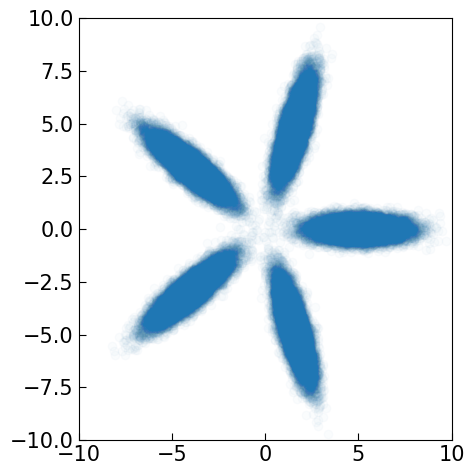

In [35]:
# Direct samples from the target mixture
x_target = target.sample((100_000,))

fig = plt.figure(figsize=(5, 5))
plt.scatter(x_target[:, 0], x_target[:, 1], alpha=0.02)
plt.xlim(-10, 10); plt.ylim(-10, 10)
plt.tight_layout()


In [36]:
def kde_2d(X, xlim=(-11, 12), ylim=(-11, 12), grid=100):
    """2D Gaussian KDE on a fixed grid; returns (xx, yy, density)."""
    xmin, xmax = xlim
    ymin, ymax = ylim
    xx, yy = np.mgrid[xmin:xmax:grid * 1j, ymin:ymax:grid * 1j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    kernel = stats.gaussian_kde(np.asarray(X).T)
    f = kernel(positions).reshape(xx.shape)
    return xx, yy, f


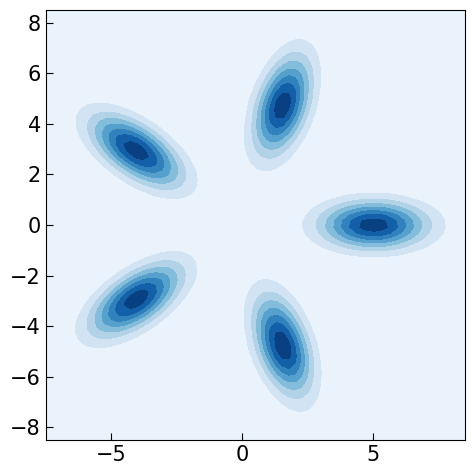

In [37]:
xx, yy, f = kde_2d(x_target.numpy())

fig = plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, f, cmap='Blues')
plt.xlim(-7.5, 8.5); plt.ylim(-8.5, 8.5)
plt.tight_layout()
# fig.savefig('GMM_marginal_density.pdf')


## 2. Reference dynamics

For the currently-active component `k`, the state follows the Langevin SDE
`dX = -C_k^{-1}(X - mu_k) dt + dW`. At each step we draw an exponential
clock with rate `lam`; if it fires, the state is rotated by `2*pi/N` and
`k -> (k+1) mod N`. The marginal distribution of this process is the
mixture from §1.


In [38]:
def simulate_dynamics(x0, lam=2.0, dt=0.01, n_steps=10**6, seed=None):
    """Euler-Maruyama for the per-component Langevin SDE plus a Poisson rotation clock."""
    rng = np.random.default_rng(seed)
    R_rot = rotation_matrix(ANGLE)
    d = x0.shape[0]
    traj = np.zeros((n_steps + 1, d))
    traj[0] = x0
    k = 0
    for t in range(n_steps):
        drift = -np.linalg.solve(Cs[k], traj[t] - mus[k])
        proposal = traj[t] + dt * drift + np.sqrt(dt) * rng.standard_normal(d)
        if rng.random() < lam * dt:
            traj[t + 1] = R_rot @ proposal
            k = (k + 1) % N_MIXTURE
        else:
            traj[t + 1] = proposal
    return traj


In [39]:
# 10^6 steps; cache to disk on first run.
CACHE = Path('GMM_dt001_1e6samples.npy')

if CACHE.exists():
    res = np.load(CACHE)
    print(f'loaded cached trajectory: {res.shape}')
else:
    print('cache miss: simulating 10**6 steps...')
    t0 = time.time()
    res = simulate_dynamics(mus[0], lam=2.0, dt=0.01, n_steps=10**6, seed=0)
    print(f'done in {time.time() - t0:.1f}s; saving to {CACHE}')
    np.save(CACHE, res)


loaded cached trajectory: (1000001, 2)


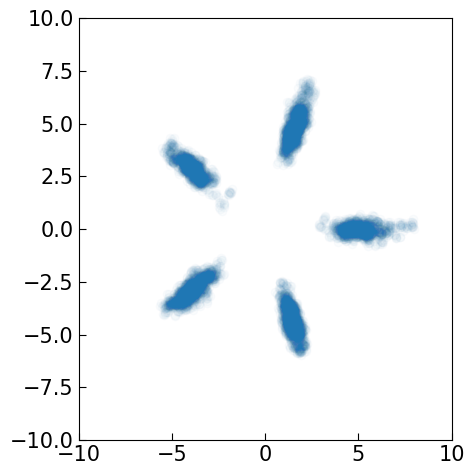

In [40]:
# Marginal of the dynamics — should look like §1's mixture.
fig = plt.figure(figsize=(5, 5))
plt.scatter(res[:10**4, 0], res[:10**4, 1], alpha=0.02)
plt.xlim(-10, 10); plt.ylim(-10, 10)
plt.tight_layout()


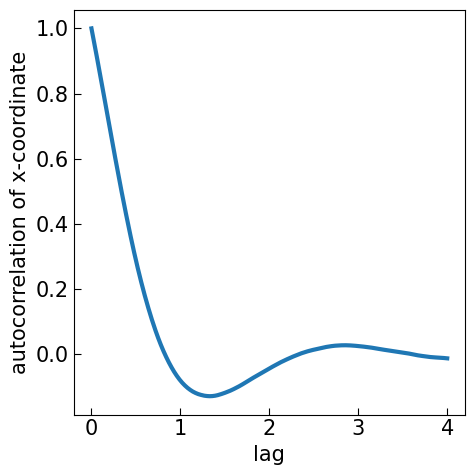

In [41]:
def autocorrelation(x, max_lag):
    out = np.ones(max_lag + 1)
    for k in range(1, max_lag + 1):
        out[k] = np.corrcoef(x[:-k], x[k:])[0, 1]
    return out


arr = res[10**3:10**6, 0]
max_lag = 400
acf = autocorrelation(arr, max_lag)
lag_t = np.arange(max_lag + 1) * 0.01

fig = plt.figure(figsize=(5, 5))
plt.plot(lag_t, acf)
plt.xlabel('lag')
plt.ylabel('autocorrelation of x-coordinate')
plt.tight_layout()
# fig.savefig('GMM_autocor.pdf')


## 3. Build training pairs `(X_t, X_{t+1})`

The trajectory is highly autocorrelated, so we subsample every 50 steps
(effective gap `dt * 50 = 0.5`, well past where the autocorrelation has
decayed) before forming consecutive pairs. 90 / 10 split for train / test.


In [42]:
torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SUBSAMPLE = 50
LAG = 1

data = torch.tensor(res[10**4::SUBSAMPLE], dtype=torch.float)
N, d = data.shape
n_train = int(0.9 * N)

train_now = data[:n_train]
train_future = data[LAG:n_train + LAG]
test_now = data[n_train:-LAG]
test_future = data[n_train + LAG:]

print(f'[dataset] size of dataset {N}*{d}')
print(train_now.mean(), train_now.max(), train_now.min(),
      train_future.pow(2).mean().sqrt())


[dataset] size of dataset 19801*2
tensor(-0.0164) tensor(7.8796) tensor(-7.5432) tensor(3.5922)


In [43]:
train_now.mean(dim=0), train_now.std(dim=0)


(tensor([-0.0208, -0.0120]), tensor([3.5940, 3.5907]))

In [44]:
test_now.mean(dim=0), test_now.std(dim=0)


(tensor([ 0.0038, -0.0675]), tensor([3.5709, 3.6038]))

## 4. Drift network

A plain MLP that maps `(z_t, t, X_t)` -> drift. Input is the
concatenation of the interpolant state `z_t` (2D), the conditioning
`X_t` (2D), and the scalar interpolant time `t`; output is 2D. Six
hidden layers of width 500 with ReLU.


In [45]:
class Velocity(nn.Module):
    def __init__(self, state_dim=2, cond_dim=2, hidden=500, depth=6):
        super().__init__()
        widths = [state_dim + cond_dim + 1] + [hidden] * depth + [state_dim]
        layers = []
        for i in range(len(widths) - 1):
            layers.append(nn.Linear(widths[i], widths[i + 1]))
            if i < len(widths) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
        n_params = sum(p.numel() for p in self.parameters())
        print(f'[Velocity] num params: {n_params:,}')

    def forward(self, zt, t, cond):
        return self.net(torch.cat([zt, cond, t[:, None]], dim=1))


## 5. Stochastic interpolant, EM sampler, trainer

We use
$$
z_t = (1-t)\,z_0 + t^2\,z_1 + \epsilon (1-t)\sqrt{t}\,\xi,\quad \xi \sim \mathcal N(0, I),
$$
which corresponds to $\alpha(t) = 1-t$, $\beta(t) = t^2$,
$\sigma(t) = \epsilon(1-t)$, $\gamma(t) = \sigma(t)\sqrt{t}$. The
network learns the drift target $\dot\alpha z_0 + \dot\beta z_1 + \dot\sigma\sqrt{t}\,\xi$;
generation uses Euler-Maruyama with diffusion coefficient $\sigma(t)$ from
$z_0 = X_t$ to $z_1 \approx X_{t+1}$.


In [46]:
class Interpolants:
    def __init__(self, sigma_coef=1.0):
        self.sigma_coef = sigma_coef
        print(f'[Interpolants] sigma_coef = {sigma_coef}')

    # coefficient schedules (all return shape matching t)
    def alpha(self, t):     return 1 - t
    def alpha_dot(self, t): return -torch.ones_like(t)
    def beta(self, t):      return t ** 2
    def beta_dot(self, t):  return 2 * t
    def sigma(self, t):     return self.sigma_coef * (1 - t)
    def sigma_dot(self, t): return -self.sigma_coef * torch.ones_like(t)
    def gamma(self, t):     return self.sigma(t) * t.sqrt()

    def interpolate(self, z0, z1, noise, t):
        t_ = t[:, None]
        return self.alpha(t_) * z0 + self.beta(t_) * z1 + self.gamma(t_) * noise

    def drift_target(self, z0, z1, noise, t):
        t_ = t[:, None]
        return (self.alpha_dot(t_) * z0
                + self.beta_dot(t_) * z1
                + (self.sigma_dot(t_) * t_.sqrt()) * noise)


In [47]:
class EulerMaruyama:
    """Generative SDE solver: x0 -> x1 via dz = b(z, t, cond) dt + sigma(t) dW."""
    def __init__(self, interpolant, t_min=0.0, t_max=1.0):
        self.I = interpolant
        self.t_min, self.t_max = t_min, t_max

    @torch.no_grad()
    def sample(self, model, x0, n_steps=2000):
        cond = x0
        zt = x0.clone()
        ts = torch.linspace(self.t_min, self.t_max, n_steps, device=x0.device)
        dt = ts[1] - ts[0]
        ones = torch.ones(zt.shape[0], device=zt.device)
        for t_scalar in ts:
            t = t_scalar * ones
            b = model(zt, t, cond=cond)
            g = self.I.sigma(t)[:, None]
            zt_mean = zt + b * dt
            zt = zt_mean + g * torch.randn_like(zt_mean) * dt.sqrt()
        return zt_mean


In [48]:
class Trainer:
    def __init__(self, model, interpolant, sampler, *,
                 train_now, train_future, test_now, test_future,
                 batch_size=10_000, base_lr=1e-3, max_steps=3000,
                 sample_every=2000, print_every=10,
                 max_grad_norm=1.0, cosine_lr=True, device='cuda'):
        self.model = model.to(device)
        self.I = interpolant
        self.sampler = sampler
        self.device = device
        self.base_lr = base_lr
        self.max_steps = max_steps
        self.sample_every = sample_every
        self.print_every = print_every
        self.max_grad_norm = max_grad_norm
        self.cosine_lr = cosine_lr
        self.opt = torch.optim.AdamW(self.model.parameters(), lr=base_lr)
        self.t_dist = torch.distributions.Uniform(low=0.0, high=1.0)
        self.step = 0
        self.epoch = 0
        self.train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(train_now, train_future),
            batch_size=batch_size, shuffle=True)
        self.test_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(test_now, test_future),
            batch_size=batch_size, shuffle=False)
        self.ref_batch = self._make_reference(n_train=100, n_test=100)
        print(f'[Optimizer] AdamW, lr={base_lr}')

    def _make_reference(self, n_train, n_test):
        nt, ft = next(iter(self.train_loader))
        ne, fe = next(iter(self.test_loader))
        ref_now = torch.cat([nt[:n_train], ne[:n_test]]).to(self.device)
        ref_future = torch.cat([ft[:n_train], fe[:n_test]]).to(self.device)
        return ref_now, ref_future

    def _make_batch(self, now, future):
        t = self.t_dist.sample((future.shape[0],)).to(self.device)
        noise = torch.randn_like(future)
        zt = self.I.interpolate(z0=now, z1=future, noise=noise, t=t)
        target = self.I.drift_target(z0=now, z1=future, noise=noise, t=t)
        return {'zt': zt, 't': t, 'cond': now, 'target': target}

    def _loss(self, D):
        out = self.model(D['zt'], D['t'], cond=D['cond'])
        return (out - D['target']).pow(2).sum(-1).mean()

    def _optimizer_step(self):
        grad_norm = torch.nn.utils.clip_grad_norm_(
            self.model.parameters(), max_norm=self.max_grad_norm)
        self.opt.step()
        self.opt.zero_grad(set_to_none=True)
        self.step += 1
        return grad_norm

    def _adjust_lr(self):
        if not self.cosine_lr:
            return
        scale = self.step / self.max_steps
        lr = self.base_lr * 0.5 * (1 + math.cos(math.pi * scale))
        for g in self.opt.param_groups:
            g['lr'] = lr
        print(f'[Scheduler] lr = {lr:.3e}')

    @torch.no_grad()
    def _eval_reference(self):
        self.model.eval()
        now, future = self.ref_batch
        zT = self.sampler.sample(self.model, now)
        err = (zT - future).norm(dim=1) / future.norm(dim=1).mean()
        n = err.shape[0] // 2
        return err[:n].mean().item(), err[n:].mean().item()

    def fit(self):
        t0 = time.time()
        print('[Training] start')
        while self.step < self.max_steps:
            for now, future in self.train_loader:
                if self.step >= self.max_steps:
                    return
                now, future = now.to(self.device), future.to(self.device)
                self.model.train()
                loss = self._loss(self._make_batch(now, future))
                loss.backward()
                grad_norm = self._optimizer_step()
                if self.step % self.print_every == 0:
                    mins = (time.time() - t0) / 60
                    print(f'step {self.step:5d}  loss {loss.item():.4f}  '
                          f'grad {grad_norm:.2f}  {mins:.2f} min')
                if self.step % self.sample_every == 0:
                    tr, te = self._eval_reference()
                    print(f'   ref relative err -- train {tr:.3f}  test {te:.3f}')
            self.epoch += 1
            self._adjust_lr()


In [69]:
interpolant = Interpolants(sigma_coef=1.0)
sampler = EulerMaruyama(interpolant)
model = Velocity(state_dim=2, cond_dim=2, hidden=500, depth=6)

trainer = Trainer(
    model, interpolant, sampler,
    train_now=train_now, train_future=train_future,
    test_now=test_now, test_future=test_future,
    batch_size=10_000, base_lr=1e-3, max_steps=3000,
    sample_every=2000, print_every=10,
    device=device,
)

# Uncomment to train from scratch (~minutes on a single GPU):
trainer.fit()
torch.save(model.state_dict(), 'GMM_model_checkpoint.pth')


[Interpolants] sigma_coef = 1.0
[Velocity] num params: 1,256,502
[Optimizer] AdamW, lr=0.001
[Training] start
[Scheduler] lr = 1.000e-03
[Scheduler] lr = 1.000e-03
[Scheduler] lr = 1.000e-03
[Scheduler] lr = 1.000e-03
step    10  loss 44.2480  grad 295.19  0.01 min
[Scheduler] lr = 1.000e-03
[Scheduler] lr = 1.000e-03
[Scheduler] lr = 9.999e-04
[Scheduler] lr = 9.999e-04
[Scheduler] lr = 9.999e-04
step    20  loss 20.8390  grad 109.42  0.02 min
[Scheduler] lr = 9.999e-04
[Scheduler] lr = 9.999e-04
[Scheduler] lr = 9.998e-04
[Scheduler] lr = 9.998e-04
[Scheduler] lr = 9.998e-04
step    30  loss 14.2480  grad 82.25  0.03 min
[Scheduler] lr = 9.998e-04
[Scheduler] lr = 9.997e-04
[Scheduler] lr = 9.997e-04
[Scheduler] lr = 9.996e-04
[Scheduler] lr = 9.996e-04
step    40  loss 11.7519  grad 41.39  0.05 min
[Scheduler] lr = 9.996e-04
[Scheduler] lr = 9.995e-04
[Scheduler] lr = 9.995e-04
[Scheduler] lr = 9.994e-04
[Scheduler] lr = 9.994e-04
step    50  loss 10.1708  grad 53.63  0.06 min
[Sche

In [70]:
checkpoint = torch.load('GMM_model_checkpoint.pth', map_location=device)
model.load_state_dict(checkpoint)


<All keys matched successfully>

## 6. Conditional forecast from a fixed initial condition

Starting from `mu_0`, roll the model forward `n_rollout` times and
compare the resulting empirical conditional distribution to the truth
(obtained by running the reference SDE for the same physical time).


In [71]:
model.eval()

n_samples = 20_000
n_rollout = 4
em_steps = 4000

x = torch.tensor(mus[0:1], dtype=torch.float32).repeat(n_samples, 1).to(device)

t0 = time.time()
with torch.no_grad():
    for k in range(n_rollout):
        x = sampler.sample(model, x, n_steps=em_steps)
        print(f'[Sampler] rollout {k + 1}/{n_rollout}, '
              f'finished in {(time.time() - t0) / 60:.2f} minutes')

forecast = x.cpu()


[Sampler] rollout 1/4, finished in 0.10 minutes
[Sampler] rollout 2/4, finished in 0.21 minutes
[Sampler] rollout 3/4, finished in 0.31 minutes
[Sampler] rollout 4/4, finished in 0.41 minutes


In [55]:
# Ground truth: run the reference SDE n_rollout * 50 = 200 steps
# from mu_0, repeated n_samples times.
init_cond = mus[0]
truth_steps = 50 * n_rollout
truth = np.zeros((n_samples, 2))

t0 = time.time()
for j in range(n_samples):
    traj = simulate_dynamics(init_cond, lam=2.0, dt=0.01,
                             n_steps=truth_steps, seed=j)
    truth[j] = traj[-1]
print(f'ground-truth samples computed in {(time.time() - t0):.1f}s')


ground-truth samples computed in 42.7s


In [ ]:
# Optional: save the densities used by the paper figures.
# out = Path('./images_for_paper')
# out.mkdir(exist_ok=True)
# np.savez(out / f'GMM_condition_density_lag{n_rollout}.npy',
#          truth=truth, result=forecast.numpy())


## 7. Compare conditional distributions

The headline plot is the marginal density of $\theta = \arctan(y/x)$:
the conditional distribution should have peaks at each component's
angular position.


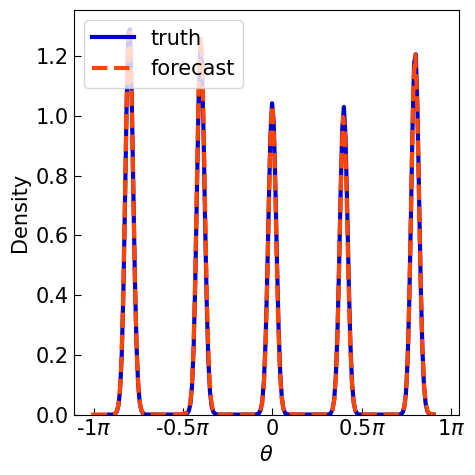

In [72]:
theta_truth = np.arctan2(truth[:, 1], truth[:, 0])
theta_forecast = torch.atan2(forecast[:, 1], forecast[:, 0]).numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
bw = 0.05 / np.std(theta_truth)
sns.kdeplot(theta_truth, bw_method=bw, label='truth',
            color='mediumblue', linestyle='solid')
sns.kdeplot(theta_forecast, bw_method=bw, label='forecast',
            color='orangered', linestyle='dashed')
ax.set_xlabel(r'$\theta$')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda v, p: rf'{v / np.pi:.0g}$\pi$' if v != 0 else '0'))
ax.xaxis.set_major_locator(MultipleLocator(base=np.pi / 2))
ax.set_xticks(np.array([-1, -0.5, 0, 0.5, 1]) * np.pi)
plt.tight_layout()
plt.show()
# fig.savefig('GMM_cond_theta.pdf')


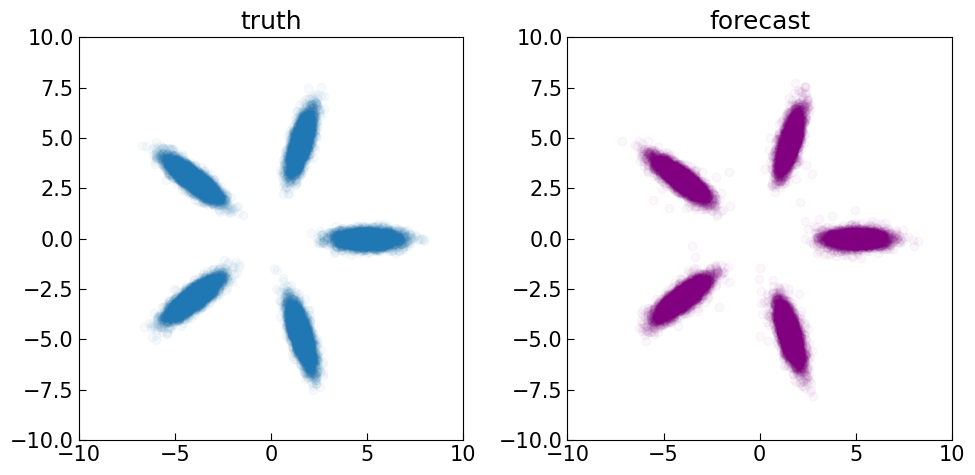

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for ax, (X, color, title) in zip(
    axs,
    [(truth, None, 'truth'),
     (forecast.numpy(), 'purple', 'forecast')],
):
    ax.scatter(X[:, 0], X[:, 1], alpha=0.03, c=color)
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_title(title)
plt.tight_layout()


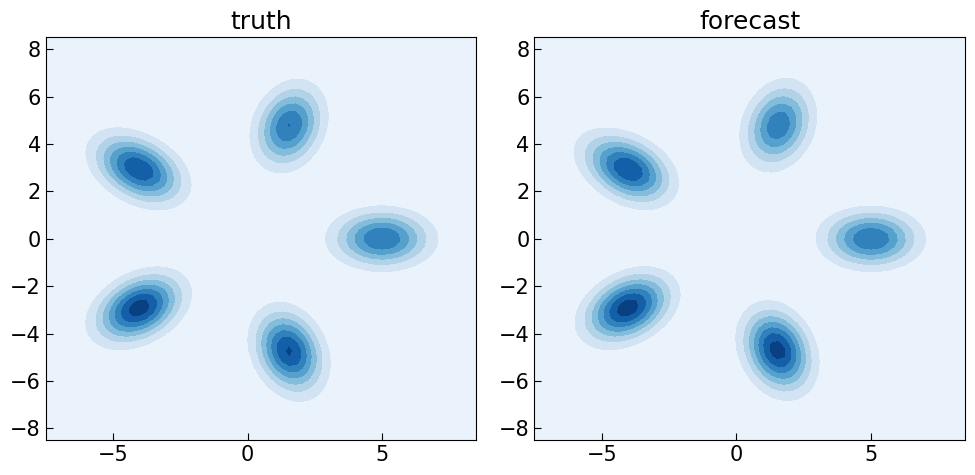

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for ax, X, title in [
    (axs[0], truth, 'truth'),
    (axs[1], forecast.numpy(), 'forecast'),
]:
    xx, yy, f = kde_2d(X)
    ax.contourf(xx, yy, f, cmap='Blues')
    ax.set_xlim(-7.5, 8.5); ax.set_ylim(-8.5, 8.5)
    ax.set_title(title)
plt.tight_layout()
# fig.savefig('GMM_cond_2Ddensity.pdf')


## 8. Marginal stats over the test set

For every test pair `(X_t, X_{t+1})` we draw one forecast sample. If the
model is correct, the forecast and the true `X_{t+1}` have the same
marginal density.


In [75]:
model.eval()
n_test = test_now.shape[0]
test_input = torch.zeros(n_test, 2)
test_truth_marginal = torch.zeros(n_test, 2)
test_result = torch.zeros(n_test, 2)

cur = 0
t0 = time.time()
for batch_idx, (now, future) in enumerate(trainer.test_loader):
    with torch.no_grad():
        n = now.shape[0]
        test_input[cur:cur + n] = now
        test_truth_marginal[cur:cur + n] = future
        test_result[cur:cur + n] = sampler.sample(
            model, now.to(device), n_steps=1000
        ).cpu()
    cur += n
    print(f'[Sampler] batch index {batch_idx}, '
          f'finished in {(time.time() - t0) / 60:.2f} minutes')


[Sampler] batch index 0, finished in 0.01 minutes


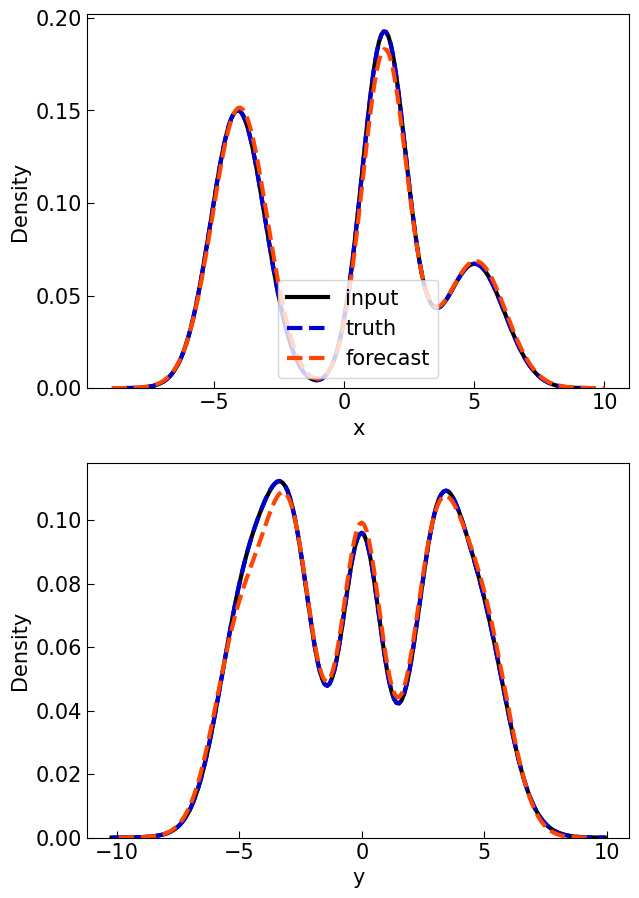

In [76]:
fig, axs = plt.subplots(2, figsize=(7, 8))
fig.subplots_adjust(bottom=-0.15)

for i, name in enumerate(['x', 'y']):
    sns.kdeplot(test_input[:, i].numpy(),           ax=axs[i],
                label='input',    color='black')
    sns.kdeplot(test_truth_marginal[:, i].numpy(),  ax=axs[i],
                label='truth',    color='mediumblue', linestyle='dashed')
    sns.kdeplot(test_result[:, i].numpy(),          ax=axs[i],
                label='forecast', color='orangered', linestyle='dashed')
    axs[i].set_xlabel(name)
axs[0].legend(loc='lower center', prop={'size': 15})
plt.show()
